In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import plot_model

In [ ]:
pill=pd.read_csv('/content/drive/Shareddrives/Codepresso_8/Drug_list/final_data/rxi_top_target.csv')

In [ ]:
import nltk
%matplotlib inline
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:
imprint=pill['imprint_str']
imprint.fillna(" ",inplace=True)

In [ ]:
num=pill['imprint_int']
num.fillna(" ",inplace=True)

In [ ]:
imprint=imprint.tolist()

In [ ]:
num=num.tolist()

In [ ]:
tokenizer=Tokenizer(filters=';')
tokenizer.fit_on_texts(imprint)
sequences = tokenizer.texts_to_sequences(imprint)

In [ ]:
tokenizer_int=Tokenizer(filters=';')
tokenizer_int.fit_on_texts(num)
sequences_int = tokenizer_int.texts_to_sequences(num)

In [ ]:
imprint_data=np.array(sequences)
num_data=np.array(sequences_int)
np.shape(imprint_data)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  


(523,)

In [ ]:
imprint_data=pad_sequences(imprint_data,maxlen=4)
num_data=pad_sequences(num_data,maxlen=4)

In [ ]:
data=tf.concat([imprint_data,num_data],axis=1)

In [ ]:
data[0]

<tf.Tensor: shape=(8,), dtype=int32, numpy=array([ 0,  0,  0, 24,  0,  0,  0,  3], dtype=int32)>

In [ ]:
data=np.array(data)

In [ ]:
type(data)

numpy.ndarray

In [ ]:
data[0]

array([ 0,  0,  0, 24,  0,  0,  0,  3], dtype=int32)

In [ ]:
from tensorflow import keras 
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
from sklearn.model_selection import train_test_split


In [ ]:
from keras.models import Sequential
from keras.layers import Dropout, Activation, Dense
from keras.layers import Flatten, Convolution2D, MaxPooling2D
from keras.models import load_model
from tensorflow.keras import models,layers
from tensorflow.keras.layers import concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam



In [ ]:
groups_folder_path="/content/drive/Shareddrives/Codepresso_8/rximage_set/imageset_rximage/images/gallery/300/"
categories=pill['drug'].unique()
num_classes=len(categories)

In [ ]:
input = keras.Input(shape=(data.shape[1:]))
x=layers.Embedding(input_dim=num_classes, output_dim=64)(input)
x=layers.Bidirectional(layers.LSTM(units=32, return_sequences=False))(x)
output = layers.Flatten()(x)

In [ ]:
model = keras.Model(
    inputs=input,
    outputs=output
)

In [ ]:
model.output

<KerasTensor: shape=(None, 64) dtype=float32 (created by layer 'flatten')>

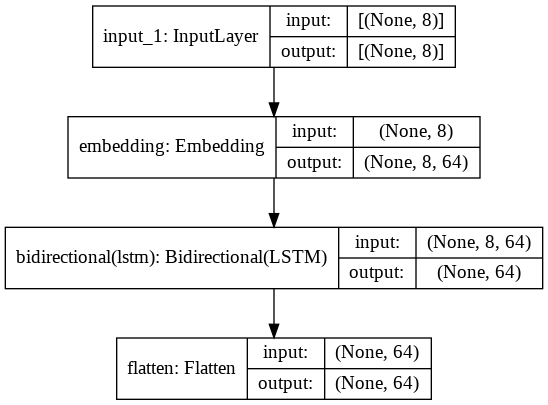

In [ ]:
plot_model(model, show_shapes=True)

# 새 섹션

In [ ]:
#이미지 읽어오기
image_w=150
image_h=150
X=[]
Y=[]
for i in range(len(pill['nlmImageFileName'])):
  image_dir=groups_folder_path+pill['nlmImageFileName'][i]
  img=cv2.imread(image_dir)
  img = cv2.resize(img, None, fx=image_w/img.shape[1], fy=image_h/img.shape[0])
  X.append(img/255.)
  label=[0 for i in range(num_classes)]
  idex=categories.tolist().index(pill['drug'][i])
  label[idex]=1
  Y.append(label)
  
X = np.array(X)
Y = np.array(Y)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,random_state=324)
data_train,data_test,Y2_train,Y2_test=train_test_split(data,Y,random_state=324)
xy = (X_train, X_test, Y_train, Y_test)


In [ ]:
from keras.models import Sequential
from keras.layers import Dropout, Activation, Dense
from keras.layers import Flatten, Convolution2D, MaxPooling2D
from keras.models import load_model
import cv2
 

model_c = Sequential()
model_c.add(Convolution2D(16, 3, 3,padding='same',activation='relu',
                        input_shape=X_train.shape[1:],name='conv1'))
model_c.add(MaxPooling2D(pool_size=(2, 2)))
model_c.add(Dropout(0.25))
  
model_c.add(Convolution2D(64, 3, 3,  activation='relu',name='conv2'))
model_c.add(MaxPooling2D(pool_size=(2, 2)))
model_c.add(Dropout(0.25))

model_c.add(Convolution2D(64, 3, 3,padding='same',name='conv3'))
model_c.add(MaxPooling2D(pool_size=(2, 2)))
model_c.add(Dropout(0.25))
  
model_c.add(Flatten())

 
model_c.save('cnntest.h5')




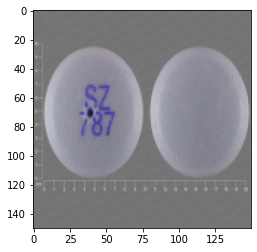

In [ ]:
plt.imshow(X_test[4])

In [ ]:
model_cnn = load_model('cnntest.h5')
model_cnn.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1 (Conv2D)               (None, 50, 50, 16)        448       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 25, 25, 16)        0         
_________________________________________________________________
dropout (Dropout)            (None, 25, 25, 16)        0         
_________________________________________________________________
conv2 (Conv2D)               (None, 8, 8, 64)          9280      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 4, 4, 64)          0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 4, 4, 64)          0         
_________________________________________________________________
conv3 (Conv2D)               (None, 2, 2, 64)          3

In [ ]:
model_cnn.output

<KerasTensor: shape=(None, 64) dtype=float32 (created by layer 'flatten_1')>

In [ ]:
combinedInput = concatenate([model.output, model_cnn.output])

In [ ]:
x=layers.Dense(256, activation = 'relu')(combinedInput)
x=layers.Dropout(0.5)(x)
x=layers.Dense(num_classes,activation = 'softmax')(x)

In [ ]:
multi_model=Model(inputs=[model.input,model_cnn.input],outputs=x)

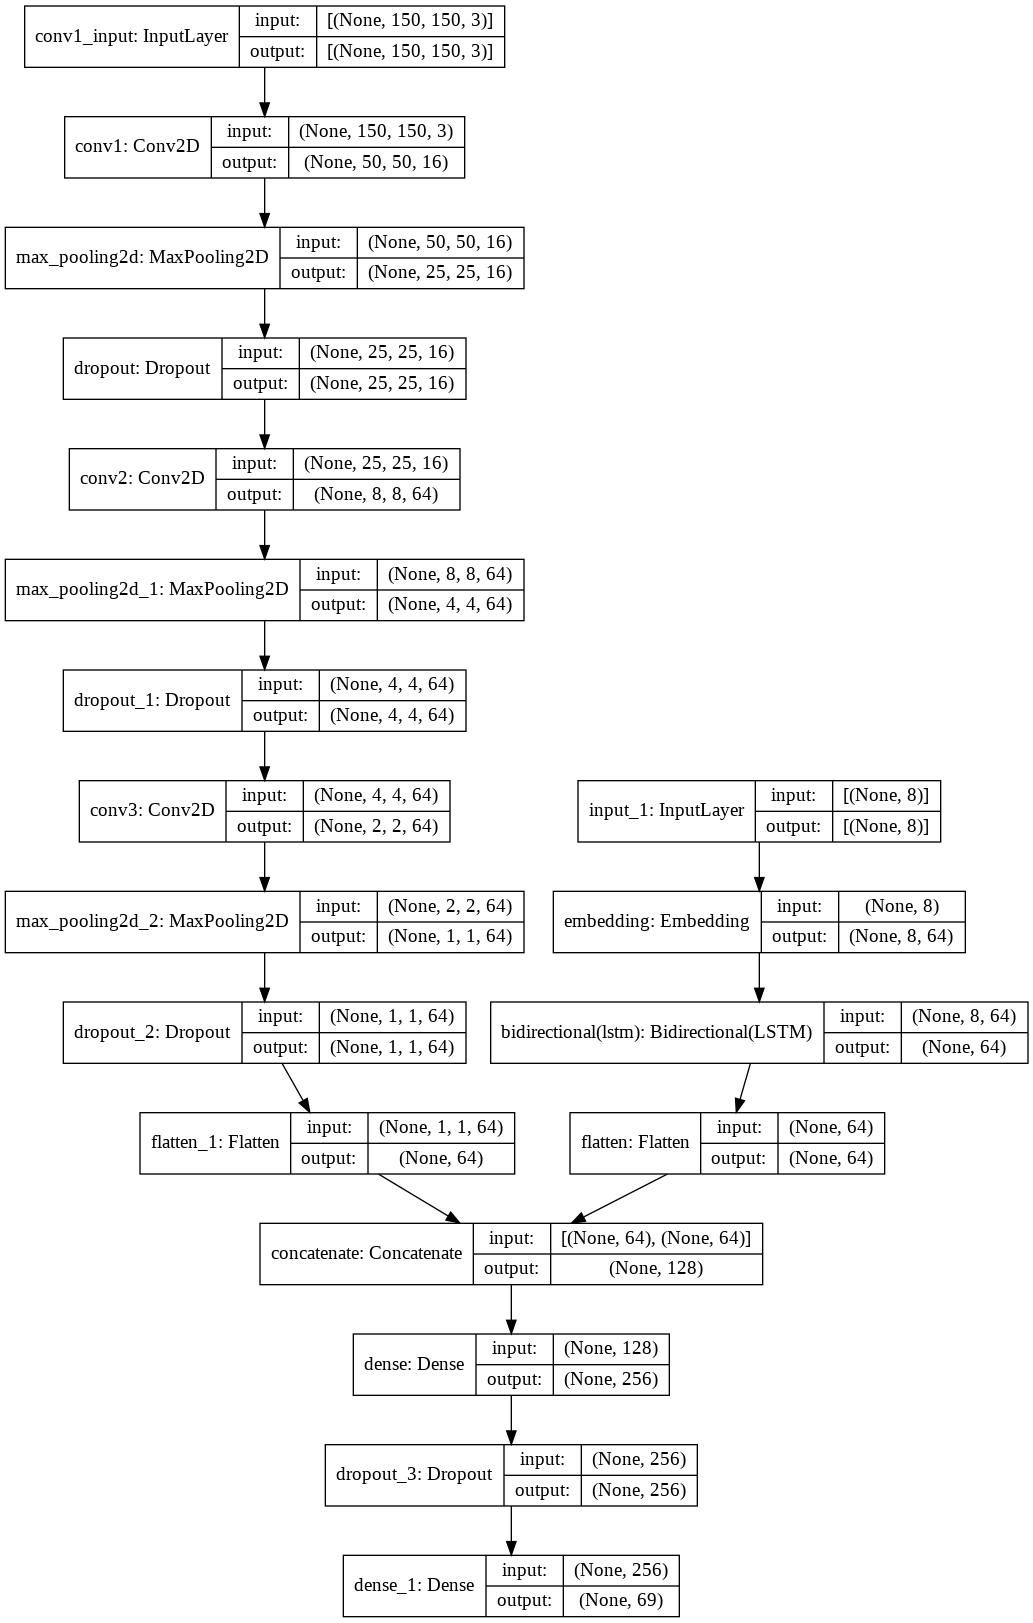

In [ ]:
plot_model(multi_model, show_shapes=True)

In [ ]:
opt = Adam(lr=1e-3, decay=1e-3 / 200)
multi_model.compile(loss='binary_crossentropy',optimizer=opt,metrics=['accuracy'])
multi_model.fit([data_train,X_train], y=Y_train,validation_split=0.2 ,batch_size=32, epochs=300)

/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/optimizer_v2.py:356: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


Epoch 1/300
10/10 [==============================] - 34s 132ms/step - loss: 0.5910 - accuracy: 0.0064 - val_loss: 0.3569 - val_accuracy: 0.0253
Epoch 2/300
10/10 [==============================] - 0s 22ms/step - loss: 0.1850 - accuracy: 0.0192 - val_loss: 0.1187 - val_accuracy: 0.0127
Epoch 3/300
10/10 [==============================] - 0s 27ms/step - loss: 0.1316 - accuracy: 0.0160 - val_loss: 0.0805 - val_accuracy: 0.0886
Epoch 4/300
10/10 [==============================] - 0s 23ms/step - loss: 0.0992 - accuracy: 0.0192 - val_loss: 0.0906 - val_accuracy: 0.0380
Epoch 5/300
10/10 [==============================] - 0s 21ms/step - loss: 0.0924 - accuracy: 0.0192 - val_loss: 0.0760 - val_accuracy: 0.0127
Epoch 6/300
10/10 [==============================] - 0s 22ms/step - loss: 0.0874 - accuracy: 0.0192 - val_loss: 0.0751 - val_accuracy: 0.0886
Epoch 7/300
10/10 [==============================] - 0s 21ms/step - loss: 0.0848 - accuracy: 0.0192 - val_loss: 0.0787 - val_accuracy: 0.0886
Epoc

In [ ]:
multi_predict=multi_model.predict([data_test,X_test])

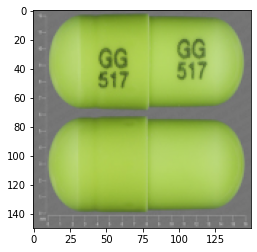

In [ ]:
plt.imshow(X_test[100])

In [ ]:
np.argmax(multi_predict[100])

13

In [ ]:
categories[13]

'terazosin'

In [ ]:
loss,accuracy=multi_model.evaluate([data_test,X_test],Y_test)

5/5 [==============================] - 0s 8ms/step - loss: 0.1258 - accuracy: 0.4427
